### Calculation of the ratio S/N

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
#In[2]:
# define function
import src.SAT_function_Obs_Fingerprint as data_process
import src.Data_Preprocess as preprosess

In [2]:
import src.slurm_cluster as scluster
client, scluster = scluster.init_dask_slurm_cluster()

/home/m/m301036/.conda/envs/mykernel/lib/python3.9/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38909 instead
  warnings.warn(


#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /scratch/m/m301036/dask_logs//dask-worker-%J.err
#SBATCH -o /scratch/m/m301036/dask_logs//dask-worker-%J.out
#SBATCH -p compute
#SBATCH -A mh0033
#SBATCH -n 1
#SBATCH --cpus-per-task=64
#SBATCH --mem=256G
#SBATCH -t 06:00:00

/home/m/m301036/.conda/envs/mykernel/bin/python -m distributed.cli.dask_worker tcp://10.128.10.130:33997 --name dummy-name --nthreads 1 --memory-limit 4.00GiB --nworkers 64 --nanny --death-timeout 60 --local-directory /scratch/m/m301036/dask_temp/ --interface ib0



### Input both the forced and ICV_std trend data 

In [3]:
output_fig_dir = "/work/mh0033/m301036/OBS_LPS_revision/docs/Figs/FIG4_intermediate_figs/"
dir_out = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG4/'

In [4]:
dir_in= '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG3/CESM2/'

CESM_forced_ds = xr.open_mfdataset(dir_in + 'forced_CESM2_MK_trend_1950-2022_sliding.nc').trend
print(CESM_forced_ds)

<xarray.DataArray 'trend' (run: 100, period: 64, lat: 90, lon: 180)>
dask.array<open_dataset-cbdc6b0aebfe6466307b3bf3e9e2be05trend, shape=(100, 64, 90, 180), dtype=float64, chunksize=(100, 64, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * run          (run) int64 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * lat          (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon          (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    realization  (run) object dask.array<chunksize=(100,), meta=np.ndarray>
  * period       (period) object '1950-2022' '1951-2022' ... '2013-2022'


In [5]:
# # Assuming `ds` is your dataset
# segment_lengths = range(10, 74, 1)  # Generate segment lengths from 10 to 73
# new_period_names = [f"forced_{length}yr_trend" for length in segment_lengths]  # Create new names

# # Replace the period coordinate
# if len(new_period_names) == len(CESM_forced_ds['tas'].period):
#     CESM_forced_ds['tas'] = CESM_forced_ds['tas'].assign_coords(period=new_period_names)
#     print("Updated period dimension successfully.")
# else:
#     print(f"Error: Mismatch in length. New names: {len(new_period_names)}, Current period: {len(CESM_forced_ds['tas'].period)}")

# # Inspect the updated dataset
# print(CESM_forced_ds)


In [6]:
CESM_forced_ds.sel(period='2013-2022')

<xarray.DataArray 'trend' (run: 100, lat: 90, lon: 180)>
dask.array<getitem, shape=(100, 90, 180), dtype=float64, chunksize=(100, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * run          (run) int64 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * lat          (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon          (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    realization  (run) object dask.array<chunksize=(100,), meta=np.ndarray>
    period       <U9 '2013-2022'

In [7]:
# Input multiple runs ICV into one dataset with new variable dimension 'run'
variable_indices = np.arange(1, 51, 1).astype(str)
segment_lengths = np.arange(10, 74, 1).astype(str)

In [8]:
# Input the standard deviation of SAT-OBS residuals
# Input the standard deviation of SAT-OBS residuals
dir_std = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG3/CESM2/'
CESM_ICV_std_ds = xr.open_mfdataset(dir_std + 'CESM2_ICV_noise_std_trend_pattern_1850_2022.nc')

In [9]:
CESM_ICV_std_ds

<xarray.Dataset>
Dimensions:       (run: 100, lat: 90, lon: 180)
Coordinates:
  * run           (run) int64 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * lat           (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon           (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables: (12/64)
    std_trend_10  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    std_trend_11  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    std_trend_12  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    std_trend_13  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    std_trend_14  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    std_trend_15  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    ...            ...
    std_trend_68  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    std_trend_69  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    std_trend_70  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    std_trend_71  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    std_trend_72  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    std_trend_73  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>

In [10]:
# define function to calculate the ratio of the trend pattern of each segment to the standard deviation of the trend pattern of each interval of segments
def SNR_trend_pattern(data, std_trend_pattern):
    """
    data: 2D array with dimensions [lat, lon]
    std_trend_pattern: 2D array with dimensions [lat, lon]
    """
    safe_std = np.where(std_trend_pattern != 0,std_trend_pattern, 1e-10)
    return data/safe_std

In [11]:
# Calculate the trend pattern of each segment and ensemble standard deviation
num = np.arange(2013, 1949, -1)
SNR_trend_pattern_ds = xr.Dataset()  # Use an xarray.Dataset to store results by key

for segment_length, num in zip(segment_lengths, num):
    # Construct the corresponding period key for the segment
    forced_key = f"{num}-2022"
    variable_name = f'SNR_{segment_length}_trend'
    
    # Debug: Print the selected forced trend period
    print(f"Processing segment length {segment_length}, forced key: {forced_key}")
    print(CESM_forced_ds.sel(period=forced_key))
    
    # Apply the SNR trend pattern function
    result = xr.apply_ufunc(
        SNR_trend_pattern,
        CESM_forced_ds.sel(period=forced_key).chunk({"run": -1}),  # Adjust chunking
        CESM_ICV_std_ds[f'std_trend_{segment_length}'].chunk({"run": -1}),  # Adjust chunking
        input_core_dims=[['lat', 'lon'], ['lat', 'lon']],  # Core dimensions
        output_core_dims=[['lat', 'lon']],                # Output retains ['lat', 'lon']
        vectorize=True,                                   # Vectorize across non-core dims
        dask='parallelized',                              # Enable parallelization
        output_dtypes=[float]                             # Output data type
    )
    
    # Assign the result to the Dataset using the variable name
    SNR_trend_pattern_ds[variable_name] = result

# Final output
# print(SNR_trend_pattern_ds)

Processing segment length 10, forced key: 2013-2022
<xarray.DataArray 'trend' (run: 100, lat: 90, lon: 180)>
dask.array<getitem, shape=(100, 90, 180), dtype=float64, chunksize=(100, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * run          (run) int64 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * lat          (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon          (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    realization  (run) object dask.array<chunksize=(100,), meta=np.ndarray>
    period       <U9 '2013-2022'
Processing segment length 11, forced key: 2012-2022
<xarray.DataArray 'trend' (run: 100, lat: 90, lon: 180)>
dask.array<getitem, shape=(100, 90, 180), dtype=float64, chunksize=(100, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * run          (run) int64 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * lat          (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon          (lon) float64 0.0 2

In [12]:
SNR_trend_pattern_ds

<xarray.Dataset>
Dimensions:       (run: 100, lat: 90, lon: 180)
Coordinates:
  * run           (run) int64 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * lat           (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon           (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    realization   (run) object dask.array<chunksize=(100,), meta=np.ndarray>
    period        <U9 '2013-2022'
Data variables: (12/64)
    SNR_10_trend  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    SNR_11_trend  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    SNR_12_trend  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    SNR_13_trend  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    SNR_14_trend  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    SNR_15_trend  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    ...            ...
    SNR_68_trend  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    SNR_69_trend  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    SNR_70_trend  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    SNR_71_trend  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    SNR_72_trend  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>
    SNR_73_trend  (run, lat, lon) float64 dask.array<chunksize=(100, 90, 180), meta=np.ndarray>

In [13]:
#save the output
import os
dir_out = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG4/'
os.makedirs(dir_out, exist_ok=True)
SNR_trend_pattern_ds.to_netcdf(dir_out + 'CESM_SNR_segments_pattern_1850_2022.nc')

/home/m/m301036/.conda/envs/mykernel/lib/python3.9/site-packages/xarray/conventions.py:232: SerializationWarning: variable realization has data in the form of a dask array with dtype=object, which means it is being loaded into memory to determine a data type that can be safely stored on disk. To avoid this, coerce this variable to a fixed-size dtype with astype() before saving it.
  warnings.warn(


In [14]:
# check the result max and min
for var in SNR_trend_pattern_ds.data_vars:
    print(var)
    print(SNR_trend_pattern_ds[var].max().values)
    print(SNR_trend_pattern_ds[var].min().values)

SNR_10_trend
1.2535476962152918
-0.3094396333361914
SNR_11_trend
1.5985238711026588
-0.35756623567027734
SNR_12_trend
1.8419393106828978
-0.4024367424163483
SNR_13_trend
2.1529225648455586
-0.444427556035281
SNR_14_trend
2.620600960767485
-0.48735755264872976
SNR_15_trend
3.0826110845490087
-0.5510469242929
SNR_16_trend
3.4941930453442627
-0.62439761505498
SNR_17_trend
3.8058175734489548
-0.6798561038974907
SNR_18_trend
4.197009073838347
-0.7280515174073336
SNR_19_trend
4.441648571093653
-0.767538876300027
SNR_20_trend
4.75748000997829
-0.8031036228742006
SNR_21_trend
5.005739680435569
-0.8269527569254741
SNR_22_trend
5.429106168892526
-0.856405800906457
SNR_23_trend
6.0235242646121
-0.9105142702728086
SNR_24_trend
6.678608297588554
-0.9795674500720372
SNR_25_trend
7.191326475056729
-1.0377429541326506
SNR_26_trend
7.655420935335907
-1.077668749115473
SNR_27_trend
8.394225738507119
-1.1291402025020045
SNR_28_trend
9.228823664072214
-1.1725977043471165
SNR_29_trend
10.256657595087628
-1

### Steps:
1. Stack the SNR values for each trend length: This will give each grid point a series of SNR values corresponding to different trend lengths.
2. Find the first trend length where SNR >= 1.0: For each grid point, check the SNR values across all trend lengths and identify the first trend length where SNR exceeds or equals 1.0.
3. Store the corresponding trend length: Create a 2D array (lat × lon) where each grid point holds the first trend length that meets the SNR condition.
4. Plot the results: Use contour shading to visualize the trend length where SNR first exceeds 1.0.

In [15]:
# Define the range of trend lengths you're analyzing
trend_lengths = np.arange(10, 74)

# Stack the data into a new dimension for trend lengths
stacked_snr = xr.concat([SNR_trend_pattern_ds[f'SNR_{t}_trend'] for t in trend_lengths], dim='trend_length')
stacked_snr = stacked_snr.assign_coords(trend_length=trend_lengths)

In [16]:
stacked_snr

<xarray.DataArray 'SNR_10_trend' (trend_length: 64, run: 100, lat: 90, lon: 180)>
dask.array<concatenate, shape=(64, 100, 90, 180), dtype=float64, chunksize=(1, 100, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * run           (run) int64 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * lat           (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon           (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    realization   (run) object dask.array<chunksize=(100,), meta=np.ndarray>
    period        <U9 '2013-2022'
  * trend_length  (trend_length) int64 10 11 12 13 14 15 ... 68 69 70 71 72 73

In [17]:
# # Define a function to find the first occurrence of SNR >= 1.0
# def first_valid_trend_length(snr_data):
#     # Use np.argmax to find the first index where SNR >= 1.0
#     condition = snr_data >= 1.0
#     first_valid_idx = np.argmax(condition, axis=0)
    
#     # If no valid index is found, set to NaN (ignore if all are less than 1.0)
#     no_valid = np.all(~condition, axis=0)
#     first_valid_idx[no_valid] = np.nan
    
#     return first_valid_idx

In [18]:
def first_valid_trend_length(snr_values):
    """
    Find the first trend length where SNR >= 2.0.
    
    Args:
    - snr_values (np.ndarray): Array of SNR values for a specific grid point across all trend lengths.
    
    Returns:
    - first_valid_idx (np.ndarray or float): The index of the first trend length where SNR >= 2.0, 
                                             or NaN if no such trend length is found.
    """
    # Mask negative SNR values by treating them as NaN
    # snr_values = np.where(snr_values < 0, np.nan, snr_values)

    # Check where SNR is >= 2.0
    condition = abs(snr_values) > 2.0
    
    # Get the index of the first valid trend length where SNR >= 2.0
    if np.any(condition):
        first_valid_idx = np.argmax(condition, axis=0)
    else:
        first_valid_idx = np.nan  # Return NaN if no trend length satisfies the condition
    
    return first_valid_idx

In [19]:
trend_lengths

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73])

In [20]:
# Apply the function to find the first trend length where SNR >= 1.0
first_trend_idx = xr.apply_ufunc(
    first_valid_trend_length, 
    stacked_snr.chunk(dict(trend_length=-1),{"run": -1}),  # Ensure the data is chunked along the trend_length dimension
    input_core_dims=[['trend_length']],  # Apply function along each grid point
    vectorize=True,                      # Apply in a vectorized way
    dask='parallelized',                 # Enable parallel computation with Dask
    output_dtypes=[float],               # Output will be float (since it may contain NaN)
)

In [21]:
first_trend_idx

<xarray.DataArray 'SNR_10_trend' (run: 100, lat: 90, lon: 180)>
dask.array<transpose, shape=(100, 90, 180), dtype=float64, chunksize=(100, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * run          (run) int64 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * lat          (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon          (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    realization  (run) object dask.array<chunksize=(100,), meta=np.ndarray>
    period       <U9 '2013-2022'

In [22]:
# Step 1: Convert first_trend_idx to integers, but keep NaNs intact
first_trend_idx_int = first_trend_idx.fillna(-1).astype(int)  # Replace NaNs with -1 temporarily

# Step 2: Map indices to actual trend lengths
first_trend_length_array = xr.DataArray(
    np.where(first_trend_idx_int >= 0, trend_lengths[first_trend_idx_int], np.nan),  # Use trend lengths for valid indices, NaN for invalid
    dims=['run','lat', 'lon'],  # Keep lat/lon dimensions
    coords={'run': first_trend_idx.run,'lat': first_trend_idx.lat, 'lon': first_trend_idx.lon}
)

In [23]:
#save the emergence data 
dir_out = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG4/'
first_trend_length_array.to_netcdf(dir_out + 'CESM_emergence_timescale.nc')

In [24]:
# output the median timescale among the realization first valid trend length in run dimension
first_trend_length_array_mean = first_trend_length_array.mean(dim='run')

In [25]:
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 16
# plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.major.right'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['savefig.transparent'] = True
plt.rcParams['pdf.fonttype'] = 42
# plt.rcParams['legend.frameon']      = False
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap

In [26]:
def plot_trend(lons, lats, data, levels=None, extend=None, cmap=None, norm=None,
                                 title="", ax=None, show_xticks=False, show_yticks=False):
    """
    Plot the trend spatial pattern using Robinson projection with significance overlaid.

    Parameters:
    - data: 2D numpy array with the trend values.
    - lats, lons: 1D arrays of latitudes and longitudes.
    - p_values: 2D array with p-values for each grid point.
    - GMST_p_values: 2D array with GMST p-values for each grid point.
    - title: Title for the plot.
    - ax: Existing axis to plot on. If None, a new axis will be created.
    - show_xticks, show_yticks: Boolean flags to show x and y axis ticks.
    
    Returns:
    - contour_obj: The contour object from the plot.
    """
# Create a new figure/axis if none is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 15), subplot_kw={'projection': ccrs.Robinson()})
        ax.set_global()
        
    # contour_obj = ax.contourf(lons, lats, data, levels=levels, extend=extend, 
    #                         cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
    # Assuming lons, lats, data, levels, cmap, norm, and extend are already defined
    pcolormesh_obj = ax.pcolormesh(lons, lats, data, norm=norm, cmap=cmap, shading='auto',
                                   transform=ccrs.PlateCarree())
    # pcolormesh_obj = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, 
    # add_colorbar=False)

    # Plot significance masks with different hatches
    # ax.contourf(lons, lats, significance_mask, levels=[0.05, 1.0],hatches=['///'], colors='none', transform=ccrs.PlateCarree())

    ax.coastlines(resolution='110m')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linewidth=1, linestyle='--',
                      color='gray', alpha=0.35)

    # Disable labels on the top and right of the plot
    gl.top_labels = False
    gl.right_labels = False

    # Enable labels on the bottom and left of the plot
    gl.bottom_labels = show_xticks
    gl.left_labels = show_yticks
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()
    gl.xlabel_style = {'size': 16}
    gl.ylabel_style = {'size': 16}
    
    if show_xticks:
        gl.bottom_labels = True
    if show_yticks:
        gl.left_labels = True
    
    ax.set_title(title, loc='center', fontsize=24, pad=5.0)

    return pcolormesh_obj

In [27]:
import copy
import matplotlib as mpl
import matplotlib.colors as mcolors
import palettable
import cartopy.util as cutil
import numpy.ma as ma

# cmdict = cmocean.cm.matter
# norm = mcolors.Normalize(vmin=10, vmax=74)

In [28]:
# save the emergence time scale of ensemble mean
# dir_out = './Fig3_CESM/output/'
first_trend_length_array_mean.to_netcdf(dir_out + 'CESM_emergence_timescale_mean.nc')

Shape of Ratio_with_cyclic: (90, 181)
Shape of lon_with_cyclic: (181,)
Shape of SNR_trend_pattern_ds.lat: (90,)


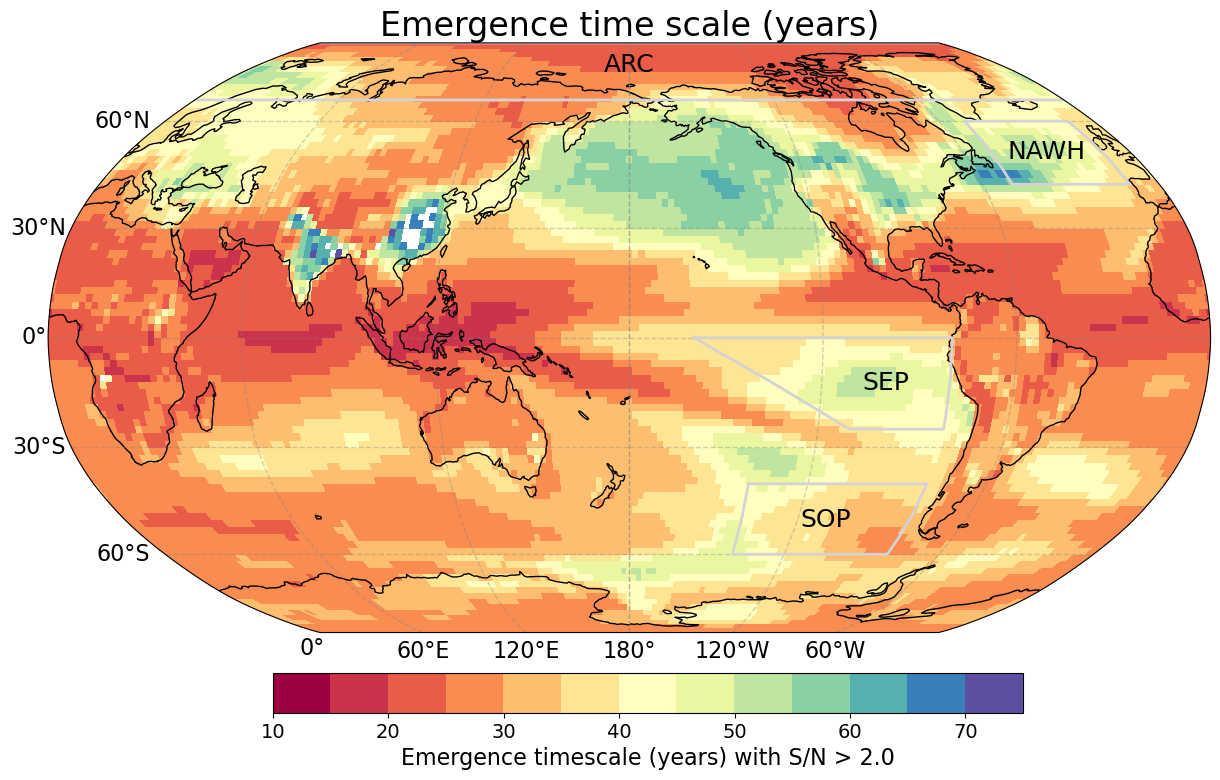

In [29]:
# Plot the first trend length where SNR >= 1.0
fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={'projection': ccrs.Robinson(180)})

trend_lengths = np.arange(10, 80, 5)  # Define the range of trend lengths
# Make a copy of the colormap before modifying it
cmap = plt.get_cmap("Spectral") #copy.copy(plt.get_cmap('OrRd_r'))  # Use 'OrRd_r' reversed colormap
# Define BoundaryNorm for discrete colormap intervals
norm = BoundaryNorm(trend_lengths, cmap.N)  # cmap.N defines the number of colors in the colormap

extend = 'neither'  # No extension beyond the colormap range
# cmdict_r = cmdict.reversed()

data_plot = first_trend_length_array_mean.values
# Mask invalid data (NaN or Inf values)
masked_array = ma.masked_invalid(data_plot)

# Add cyclic point to data and longitude
Ratio_with_cyclic, lon_with_cyclic = cutil.add_cyclic_point(masked_array, coord=first_trend_length_array.lon)

# Check the shapes to ensure consistency
print("Shape of Ratio_with_cyclic:", Ratio_with_cyclic.shape)
print("Shape of lon_with_cyclic:", lon_with_cyclic.shape)
print("Shape of SNR_trend_pattern_ds.lat:", SNR_trend_pattern_ds.lat.shape)

# Plot the data (ensure 'contour' is the correct mappable object)
pcolormesh_plot = plot_trend(lon_with_cyclic, SNR_trend_pattern_ds.lat, Ratio_with_cyclic,
                                    levels=trend_lengths, extend=extend, cmap=cmap, norm=norm,
                                        title='Emergence time scale (years)', ax=ax, show_xticks=True, show_yticks=True)


# Add the regional outlines and calculate midpoints for labels:
# Arctic box
arctic_lon_mid = (0 + 360) / 2
arctic_lat_mid = (66.5 + 90) / 2
ax.plot([0, 360, 360, 0, 0], [66.5, 66.5, 90, 90, 66.5],
        color='lightgrey', linewidth=2.0, transform=ccrs.PlateCarree())
ax.text(arctic_lon_mid, arctic_lat_mid, 'ARC', color='black', fontsize=18, transform=ccrs.PlateCarree(),
        ha='center', va='center')  # Label for Arctic

# WH box
wh_lon_mid = (310 + 350) / 2
wh_lat_mid = (42 + 60) / 2
box_lons = np.array([310, 350, 350, 310, 310])
box_lats = np.array([42, 42, 60, 60, 42])
ax.plot(box_lons, box_lats, color='lightgrey', linewidth=2.0, transform=ccrs.PlateCarree())
ax.text(wh_lon_mid, wh_lat_mid, 'NAWH', color='black', fontsize=18, transform=ccrs.PlateCarree(),
        ha='center', va='center')  # Label for WH

# Southeast Pacific box
sep_lon_mid = (200 + 320) / 2
sep_lat_mid = (0 + -25) / 2
ax.plot([200%360, 280%360, 280%360, 250%360, 200%360], [0, 0, -25, -25, 0],
        color='lightgrey', linewidth=2.0, transform=ccrs.PlateCarree())
ax.text(sep_lon_mid, sep_lat_mid, 'SEP', color='black', fontsize=18, transform=ccrs.PlateCarree(),
        ha='center', va='center')  # Label for SEP

# Extratropical South Pacific box
sop_lon_mid = (220 + 280) / 2
sop_lat_mid = (-40 + -60) / 2
ax.plot([220%360, 280%360, 280%360, 220%360, 220%360], [-40, -40, -60, -60, -40],
        color='lightgrey', linewidth=2.0, transform=ccrs.PlateCarree())
ax.text(sop_lon_mid, sop_lat_mid, 'SOP', color='black', fontsize=18, transform=ccrs.PlateCarree(),
        ha='center', va='center')  # Label for SOP
# Add colorbar for the plot

cbar_ax = fig.add_axes([0.275, 0.12, 0.5, 0.04])
cbar = plt.colorbar(pcolormesh_plot, cax=cbar_ax, orientation='horizontal')
# # Customize the colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Emergence timescale (years) with S/N > 2.0', fontsize=16)

fig.savefig(f'{output_fig_dir}CESM2_Emergence_Trend_Length.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{output_fig_dir}CESM2_Emergence_Trend_Length.pdf', dpi=300, bbox_inches='tight')
plt.show()

### 